In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tapakah68/supervisely-filtered-segmentation-person-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.31G/4.31G [00:43<00:00, 107MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tapakah68/supervisely-filtered-segmentation-person-dataset/versions/3


In [ ]:
!ls /root/.cache/kagglehub/datasets/tapakah68/supervisely-filtered-segmentation-person-dataset/versions/3/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img/
!mv /root/.cache/kagglehub/datasets/tapakah68/supervisely-filtered-segmentation-person-dataset/versions/3/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img/ ~/content/dataset

collage  images  masks


In [ ]:
!ls

dataset  sample_data


In [ ]:
IMG_SIZE   = 128
BATCH_SIZE = 16
IMG_DIR    = "dataset/images"
MASK_DIR   = "dataset/masks"

In [ ]:
all_images, all_masks = [], []

for fname in sorted(os.listdir(IMG_DIR)):
    if not fname.lower().endswith(".png"):
        continue
    mask_path = os.path.join(MASK_DIR, fname)   # same filename in both folders
    if os.path.exists(mask_path):
        all_images.append(os.path.join(IMG_DIR, fname))
        all_masks.append(mask_path)

print(f"Total pairs: {len(all_images)}")

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    all_images, all_masks, test_size=0.15, random_state=42
)
print(f"Train: {len(train_imgs)}  |  Val: {len(val_imgs)}")

Total pairs: 2667
Train: 2266  |  Val: 401


In [ ]:

mask_path = os.path.join(MASK_DIR, sorted(os.listdir(MASK_DIR))[0])
mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

print("Shape:", mask.shape)
print("dtype:", mask.dtype)
print("Unique values:", np.unique(mask))



Shape: (800, 1200, 3)
dtype: uint8
Unique values: [  0 255]


In [ ]:
print(all_images[0])
print(all_masks[0])

dataset/images/ds10_pexels-photo-687782.png
dataset/masks/ds10_pexels-photo-687782.png


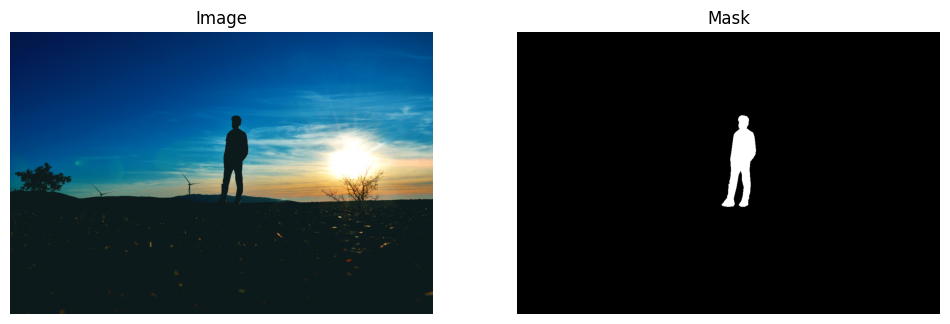

In [ ]:

image = cv2.imread(all_images[0])
mask = cv2.imread(all_masks[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Image')
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Mask')
plt.imshow(mask[:, :, 0], cmap='gray')
plt.axis('off')

plt.show()

In [ ]:
def load_and_preprocess(img_path, mask_path):
    # Image
    image = tf.io.read_file(img_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    # Mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method="nearest")
    mask = tf.cast(mask > 127, tf.int32)
    return image, mask


def make_dataset(img_list, mask_list, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((img_list, mask_list))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(500)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_dataset = make_dataset(train_imgs, train_masks, shuffle=True)
val_dataset   = make_dataset(val_imgs,   val_masks,   shuffle=False)

In [ ]:
def build_pretrained_unet(output_channels=2):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    layer_names = [
        "block_1_expand_relu",   # 64×64
        "block_3_expand_relu",   # 32×32
        "block_6_expand_relu",   # 16×16
        "block_13_expand_relu",  # 8×8
        "block_16_project",      # 4×4
    ]
    skip_outputs = [base_model.get_layer(n).output for n in layer_names]
    encoder = tf.keras.Model(inputs=base_model.input, outputs=skip_outputs)
    encoder.trainable = False   # freeze backbone

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    skips  = encoder(inputs)
    x      = skips[-1]

    for filters, skip in zip([512, 256, 128, 64], reversed(skips[:-1])):
        x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)

    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.ReLU()(x)
    outputs = layers.Conv2D(output_channels, 1, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs)


model = build_pretrained_unet(output_channels=2)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 64, 64,   │  1,841,984 │ input_layer_1[0]… │
│ (Functional)        │ 96), (None, 32,   │            │                   │
│                     │ 32, 144), (None,  │            │                   │
│                     │ 16, 16, 192),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 576), (None, 4,   │            │                   │
│                     │ 4, 320)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 512) │  1,475,072 │ functional[0][4]  │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 8, 512) │      2,048 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8,      │          0 │ re_lu[0][0],      │
│ (Concatenate)       │ 1088)             │            │ functional[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 512) │  5,014,016 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │  1,179,904 │ conv2d_1[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ re_lu_1[0][0],    │
│ (Concatenate)       │ 448)              │            │ functional[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │  1,032,448 │ concatenate_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_2[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32,    │    295,040 │ conv2d_3[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                 

 Total params: 14,474,722 (55.22 MB)

 Trainable params: 12,630,818 (48.18 MB)

 Non-trainable params: 1,843,904 (7.03 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras", monitor="accuracy"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    ),
]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    callbacks=callbacks,
)

Epoch 1/5
142/142 ━━━━━━━━━━━━━━━━━━━━ 143s 774ms/step - accuracy: 0.9313 - loss: 0.1714 - val_accuracy: 0.9258 - val_loss: 0.1861 - learning_rate: 0.0010
Epoch 2/5
142/142 ━━━━━━━━━━━━━━━━━━━━ 91s 533ms/step - accuracy: 0.9472 - loss: 0.1340 - val_accuracy: 0.8986 - val_loss: 0.3764 - learning_rate: 0.0010
Epoch 3/5
142/142 ━━━━━━━━━━━━━━━━━━━━ 85s 498ms/step - accuracy: 0.9559 - loss: 0.1133 - val_accuracy: 0.9535 - val_loss: 0.1219 - learning_rate: 0.0010
Epoch 4/5
142/142 ━━━━━━━━━━━━━━━━━━━━ 86s 505ms/step - accuracy: 0.9606 - loss: 0.1018 - val_accuracy: 0.9538 - val_loss: 0.1237 - learning_rate: 0.0010
Epoch 5/5
142/142 ━━━━━━━━━━━━━━━━━━━━ 78s 447ms/step - accuracy: 0.9629 - loss: 0.0959 - val_accuracy: 0.9578 - val_loss: 0.1141 - learning_rate: 0.0010


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


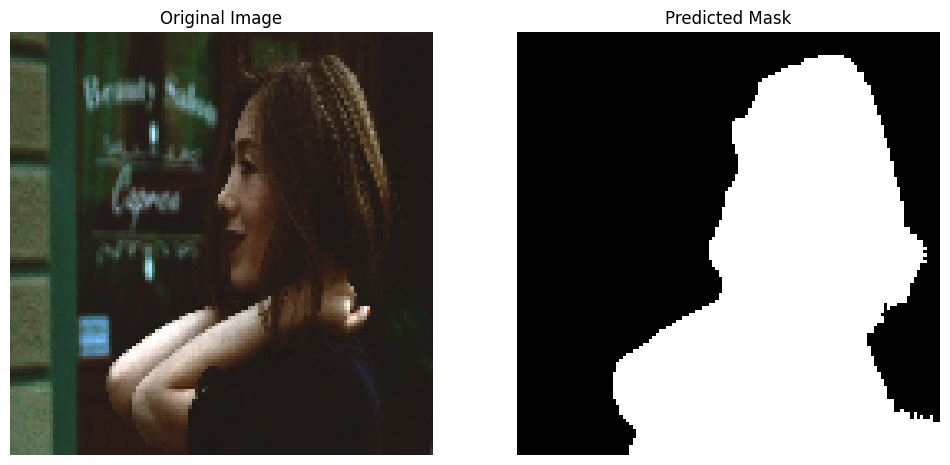

In [68]:
import random

# Select a random image from the validation set
idx = random.randint(0, len(val_imgs) - 1)
random_img_path = val_imgs[idx]
random_mask_path = val_masks[idx]

# Load and preprocess the image (similar to load_and_preprocess but just for one image)
original_image = tf.io.read_file(random_img_path)
original_image = tf.image.decode_png(original_image, channels=3)
original_image_display = tf.image.resize(original_image, (IMG_SIZE, IMG_SIZE))
original_image_display = tf.cast(original_image_display, tf.uint8).numpy()

processed_image = tf.image.resize(original_image, (IMG_SIZE, IMG_SIZE))
processed_image = tf.cast(processed_image, tf.float32)
processed_image = tf.keras.applications.mobilenet_v2.preprocess_input(processed_image)

# Add batch dimension for model prediction
processed_image = tf.expand_dims(processed_image, 0)

# Predict the mask
predicted_mask = model.predict(processed_image)
predicted_mask = tf.argmax(predicted_mask, axis=-1)
predicted_mask = predicted_mask[0, ..., tf.newaxis]
predicted_mask = tf.cast(predicted_mask, tf.float32).numpy()

# Display the original image and the predicted mask
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(original_image_display)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Predicted Mask')
plt.imshow(predicted_mask[:, :, 0], cmap='gray')
plt.axis('off')

plt.show()

In [ ]:
model.save('person_segmentation_model.keras')